# RNN
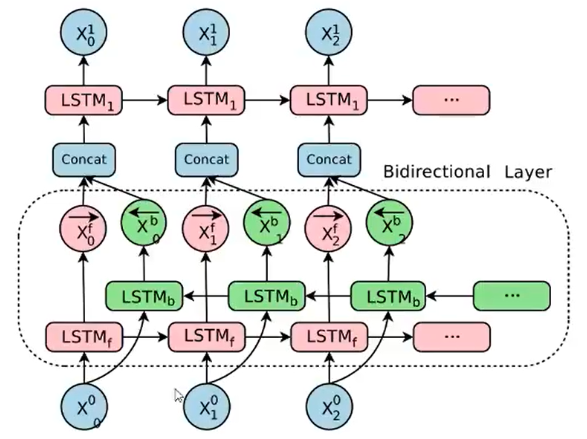

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

In [ ]:
# translate from Chinese to English

# vocabulary example(Chinese-->English)
chinese_sentences = [
    ["我", "爱", "学习"],
    ["你", "好", "吗"],
    ["今天", "天气", "很好"]
]

english_sentences = [
    ["I", "love", "learning"],
    ["How", "are", "you"],
    ["Today", "weather", "is", "good"]
]

# create
# <PAD>Padding;<SOS>Start of Sequence;<EOS>End of Sequence
chinese_vocab = {"<PAD>": 0, "<SOS>": 1, "<EOS>": 2}
for sentence in chinese_sentences:
    for word in sentence:
        if word not in chinese_vocab:
            chinese_vocab[word] = len(chinese_vocab)

english_vocab = {"<PAD>": 0, "<SOS>": 1, "<EOS>": 2}
for sentence in english_sentences:
    for word in sentence:
        if word not in english_vocab:
            english_vocab[word] = len(english_vocab)

# Encoder
class EncoderRNN(nn.Module):
    def __init__(self, input_size, hidden_size):
        super(EncoderRNN, self).__init__()
        self.hidden_size = hidden_size
        self.embedding = nn.Embedding(input_size, hidden_size)
        self.gru = nn.GRU(hidden_size, hidden_size)
    
    def forward(self, input, hidden):
        embedded = self.embedding(input).view(1, 1, -1)
        output, hidden = self.gru(embedded, hidden)
        return output, hidden
    
    def init_hidden(self):
        return torch.zeros(1, 1, self.hidden_size)

# Decoder
class DecoderRNN(nn.Module):
    def __init__(self, hidden_size, output_size):
        super(DecoderRNN, self).__init__()
        self.hidden_size = hidden_size
        self.embedding = nn.Embedding(output_size, hidden_size)
        self.gru = nn.GRU(hidden_size, hidden_size)
        self.out = nn.Linear(hidden_size, output_size)
        self.softmax = nn.LogSoftmax(dim=1)
    
    def forward(self, input, hidden):
        output = self.embedding(input).view(1, 1, -1)
        output = torch.relu(output)
        output, hidden = self.gru(output, hidden)
        output = self.softmax(self.out(output[0]))
        return output, hidden

# train
def train(input_tensor, target_tensor, encoder, decoder, 
          encoder_optimizer, decoder_optimizer, criterion):
    encoder_hidden = encoder.init_hidden()
    
    encoder_optimizer.zero_grad()
    decoder_optimizer.zero_grad()
    
    input_length = input_tensor.size(0)
    target_length = target_tensor.size(0)
    
    loss = 0
    
    # encoder input
    for ei in range(input_length):
        encoder_output, encoder_hidden = encoder(input_tensor[ei], encoder_hidden)
    
    # init input is SOS token
    decoder_input = torch.tensor([[english_vocab["<SOS>"]]])
    decoder_hidden = encoder_hidden
    
    # decoder output
    for di in range(target_length):
        decoder_output, decoder_hidden = decoder(decoder_input, decoder_hidden)
        loss += criterion(decoder_output, target_tensor[di])
        decoder_input = target_tensor[di]  # 教师强制
    
    loss.backward()
    encoder_optimizer.step()
    decoder_optimizer.step()
    
    return loss.item() / target_length

# param
hidden_size = 256
learning_rate = 0.01
n_iters = 1000

# init model
encoder = EncoderRNN(len(chinese_vocab), hidden_size)
decoder = DecoderRNN(hidden_size, len(english_vocab))

# opti & lossfun
encoder_optimizer = optim.SGD(encoder.parameters(), lr=learning_rate)
decoder_optimizer = optim.SGD(decoder.parameters(), lr=learning_rate)
criterion = nn.NLLLoss()

# train
for iter in range(1, n_iters + 1):
    # for simple，actually choose sample randomly
    training_pair = (chinese_sentences[0], english_sentences[0])
    input_tensor = torch.tensor([chinese_vocab[word] for word in training_pair[0]], dtype=torch.long)
    target_tensor = torch.tensor([english_vocab[word] for word in training_pair[1]], dtype=torch.long)
    
    loss = train(input_tensor, target_tensor, encoder, decoder, 
                 encoder_optimizer, decoder_optimizer, criterion)
    
    if iter % 100 == 0:
        print(f'Iteration {iter}, Loss: {loss:.4f}')

# test
def translate(sentence, encoder, decoder):
    with torch.no_grad():
        input_tensor = torch.tensor([chinese_vocab[word] for word in sentence], dtype=torch.long)
        encoder_hidden = encoder.init_hidden()
        
        for ei in range(input_tensor.size(0)):
            encoder_output, encoder_hidden = encoder(input_tensor[ei], encoder_hidden)
        
        decoder_input = torch.tensor([[english_vocab["<SOS>"]]])
        decoder_hidden = encoder_hidden
        
        decoded_words = []
        
        for di in range(20):  # max length output
            decoder_output, decoder_hidden = decoder(decoder_input, decoder_hidden)
            topv, topi = decoder_output.data.topk(1)
            if topi.item() == english_vocab["<EOS>"]:
                break
            decoded_words.append(list(english_vocab.keys())[list(english_vocab.values()).index(topi.item())])
            decoder_input = topi.squeeze().detach()
        
        return ' '.join(decoded_words)

# 
test_sentence = ["我", "爱", "学习"]
print(f"中文: {' '.join(test_sentence)}")
print(f"英文翻译: {translate(test_sentence, encoder, decoder)}")